<a href="https://colab.research.google.com/github/11239m006/opencv/blob/main/opencv08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To detect and classify shapes (Triangle, Rectangle, Circle) from an image using OpenCV  


Grayscale conversion

Thresholding

Contour detection

Shape approximation

Drawing and labeling


Read the input image.


Convert to grayscale.


Apply Gaussian blur (noise removal).


Apply thresholding.


Detect contours.


Approximate contour shape using approxPolyDP().


Identify shape based on number of sides.


Draw contour and label the shape.


Display output.

Threshold Image


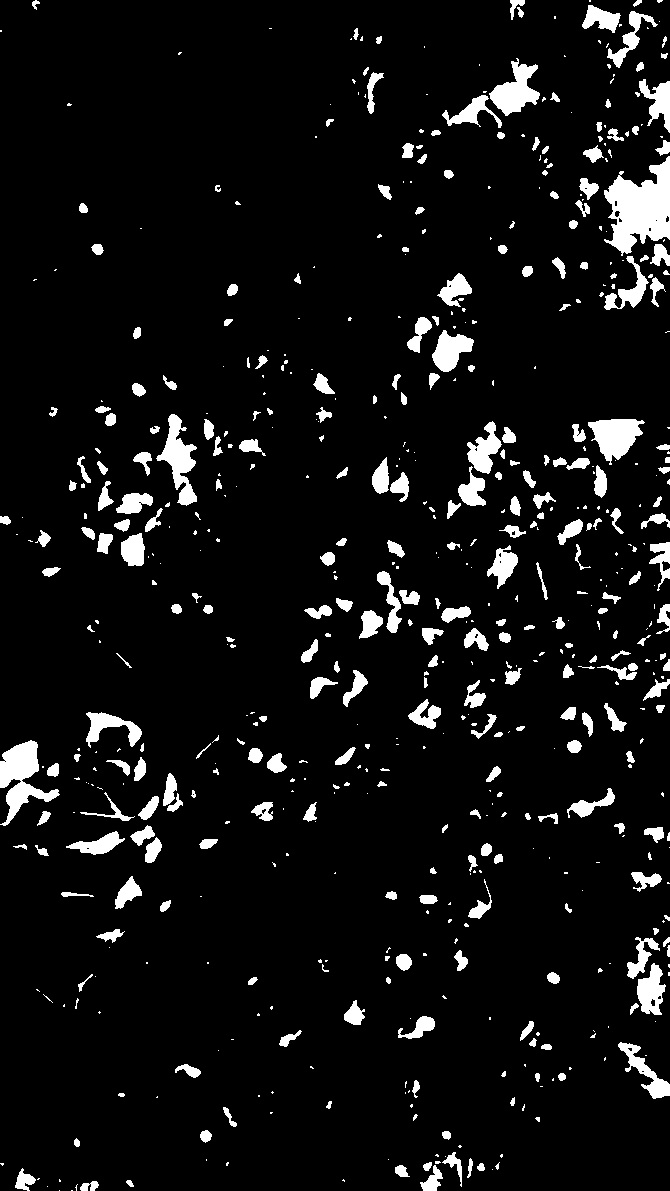

Detected Shapes


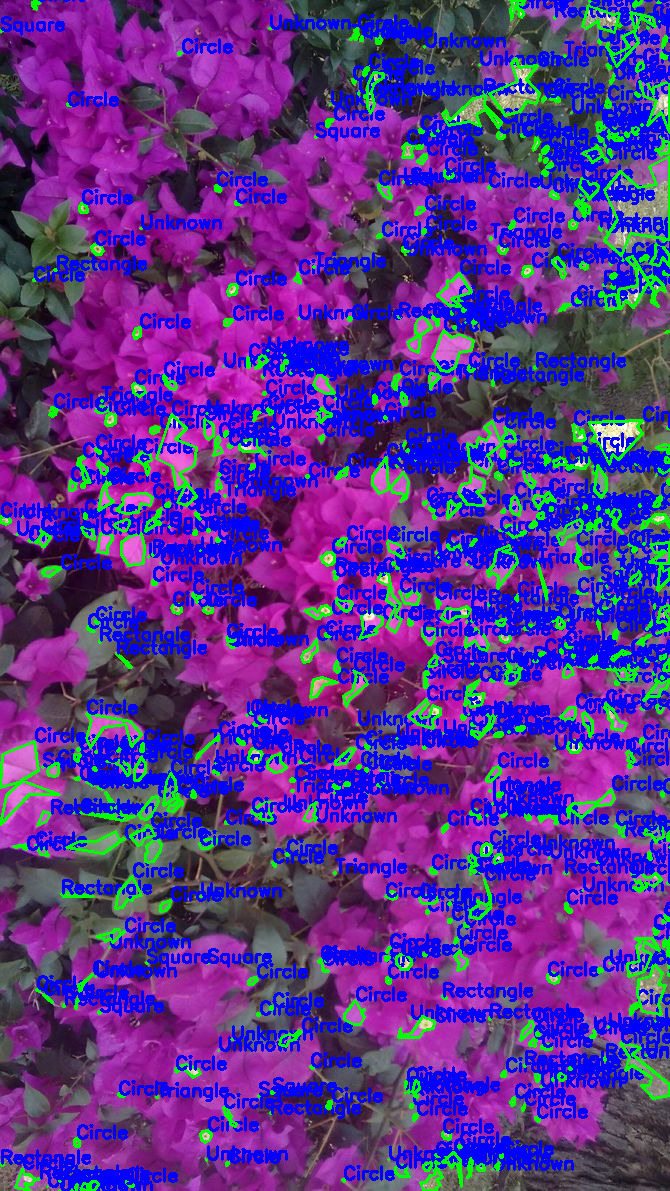

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Step 1: Read image
img = cv2.imread('/content/bougainvillea_00002.jpg')

if img is None:
    print("Error: Image not loaded")
else:
    output = img.copy()

    # Step 2: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 3: Gaussian Blur (noise removal)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Step 4: Thresholding
    _, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

    # Step 5: Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        # Step 6: Approximate shape
        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        sides = len(approx)

        # Step 7: Identify shape
        if sides == 3:
            shape = "Triangle"
        elif sides == 4:
            # Check for square vs rectangle (optional)
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)

            if 0.95 <= aspect_ratio <= 1.05:
                shape = "Square"
            else:
                shape = "Rectangle"
        elif sides > 4:
            shape = "Circle"
        else:
            shape = "Unknown"

        # Step 8: Draw contour
        cv2.drawContours(output, [approx], -1, (0, 255, 0), 2)

        # Step 9: Label shape
        x, y = approx[0][0]
        cv2.putText(output, shape, (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255, 0, 0), 2)

    # Step 10: Display output
    print("Threshold Image")
    cv2_imshow(thresh)

    print("Detected Shapes")
    cv2_imshow(output)